In [1]:
import numpy as np
from skimage.draw import disk
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from model.Solver import Solver
from model.Utils.Plot import plot_simulation
import torch
import seaborn as sns
radius = 13

In [2]:
def dna_diffusion(dna_initial,region,para,crit,steps):
    region[region<crit] = 0
    region_hat = np.fft.fft2(region)
    M,N,step = para["m"],para["n"],0.1
    xx,yy = np.meshgrid(2 * np.pi / M * np.concatenate([np.arange(0, M / 2), np.arange(-M / 2, 0)])
                         , 2 * np.pi / N * np.concatenate([np.arange(0, N / 2), np.arange(-N / 2, 0)]))
    nk2 = xx ** 2 + yy ** 2
    region_x = np.fft.ifft2(xx*region_hat).real/(region+1e-3)
    region_y = np.fft.ifft2(yy*region_hat).real/(region+1e-3)
    chi_hat = {key:np.fft.fft2(value) for key,value in dna_initial.items()}
    for i in range(steps):
        last_chihat = chi_hat
        for key,value in dna_initial.items():
            Dd= para["Dd_{}".format(key)]
            chi_x = np.fft.ifft2(xx * last_chihat[key]).real
            chi_y = np.fft.ifft2(yy * last_chihat[key]).real
            chi_hat[key] = (last_chihat[key] + Dd*step*np.fft.fft2(region_x*chi_x+region_y*chi_y))/(1+Dd*step*nk2)
    chi = {key:np.fft.ifft2(value).real for key,value in chi_hat.items()}
    return chi

In [3]:
def init_dnadiff(para,dna_level_0=0.5,dna_level_1=0.5,dna_level_1_reset=1.2,diffused_limit=None,diffused_time0=2000,diffused_time1=1500):
    n,m,base,crit = map(para.get,["n","m","base","Critical"])
    # generate disk/ring or mask
    disk_rr,disk_cc = disk((n/2,m/2),radius)#13
    disk_mask_ini = np.zeros([n,m])
    disk_mask_ini[disk_rr,disk_cc] = 1
    dna_ring_outer,dna_ring_inner = disk((n/2,m/2),radius+5),disk((n/2,m/2),radius+2)
    dna_region = np.zeros_like(disk_mask_ini)
    dna_region[dna_ring_outer] = 1
    mask = np.zeros([n,m])
    mask[dna_ring_outer] = 1;mask[dna_ring_inner] = 0
    dna_ring_rr,dna_ring_cc = np.where(mask==1)[0],np.where(mask==1)[1]
    # DNA diffusion
    coupled_filtered = gaussian_filter(dna_region,sigma=3)
    dna_0 = np.zeros_like(coupled_filtered)
    dna_0[dna_ring_rr,dna_ring_cc] = dna_level_0
    # Initialize the DNA region as ring outside
    dna_initial = {"0":dna_0}
    if "Dd_1" in para.keys():
        dna_1 = np.zeros_like(disk_mask_ini)
        dna_1[dna_ring_rr,dna_ring_cc] = dna_level_1
        # Initialize the DNA region
        dna_initial.update({"1":dna_1})
    if diffused_limit is not None:
        # Restrict initial diffused components
        dna_target_initial = {key:dna_initial.get(key) for key in diffused_limit}
    else:
        dna_target_initial = dna_initial.copy()
    target_diffused = dna_diffusion(dna_target_initial,coupled_filtered,para,0,diffused_time0)
    # Prepare phi and eta
    diffused_dna = dna_initial.copy()
    if diffused_limit is not None:
        for dna_key in diffused_limit:
            diffused_dna[dna_key] = target_diffused[dna_key]
    else:
        diffused_dna = target_diffused.copy()
    invasive_dna = diffused_dna["0"] * disk_mask_ini
    if "Dd_1" in para.keys():
        invasive_dna += 0.2*(diffused_dna["1"] * disk_mask_ini)
        new_radius = np.sqrt((6*invasive_dna.sum()+np.pi*radius**2)/(np.pi))
        # Restrict on diffusion region of Low
        aux_dna_radius = np.sqrt((diffused_dna["1"].sum()/np.pi+(new_radius)**2))
        assert aux_dna_radius > radius
        aux_ring_outer = disk((n/2,m/2),aux_dna_radius)
        aux_ring_inner = disk((n/2,m/2),new_radius)
        mask_aux = np.zeros([n,m])
        mask_aux[aux_ring_outer] = 1;mask_aux[aux_ring_inner] = 0
        aux_ring_rr,aux_ring_cc = np.where(mask_aux==1)[0],np.where(mask_aux==1)[1]
        aux_dna = np.zeros_like(disk_mask_ini)
        aux_dna[aux_ring_rr,aux_ring_cc] = dna_level_1_reset
        new_dna_region = np.zeros_like(disk_mask_ini)
        new_dna_region[aux_ring_inner] = 1
        new_dna_region = gaussian_filter(new_dna_region,sigma=3)
        diffused_dna_1 = dna_diffusion({"1":aux_dna},new_dna_region,para,0,diffused_time1)
        diffused_dna["1"] = diffused_dna_1["1"]
    new_radius = np.sqrt((6*invasive_dna.sum()+np.pi*radius**2)/(np.pi))
    print(new_radius)
    disk_rr,disk_cc = disk((n/2,m/2),new_radius)#13
    disk_mask = np.zeros([n,m])
    disk_mask[disk_rr,disk_cc] = 1
    rr_ring_outer,cc_ring_outer = disk((n/2,m/2),new_radius+2)
    rr_ring_inner,cc_ring_inner = disk((n/2,m/2),new_radius-2)
    mask = np.zeros([n,m])
    mask[rr_ring_outer,cc_ring_outer] = 1;mask[rr_ring_inner,cc_ring_inner] = 0
    ring_rr,ring_cc= np.where(mask==1)[0],np.where(mask==1)[1]
    phi_hyphilic = np.zeros([n,m])
    phi_hyphobic = np.zeros([n,m])
    num_roi = len(disk_rr)
    phi_hyphilic[disk_rr,disk_cc] = base/6*5+ np.random.randn(num_roi)/100000
    phi_hyphobic[disk_rr,disk_cc] = base/6*7+ np.random.randn(num_roi)/100000
    eta = phi_hyphobic + phi_hyphilic - crit
    phi = phi_hyphilic - phi_hyphobic
    phi[ring_rr,ring_cc]=0.2
    eta = gaussian_filter(eta,sigma=3)
    phi = gaussian_filter(phi,sigma=3)
    return eta,phi,diffused_dna
def plotDP(dna,protein):
    #dna = {key:gaussian_filter(value,sigma=3) for key,value in dna_initial.items()}
    fig_main,axs_main = plt.subplots(2,3,figsize=(15,6),gridspec_kw={'width_ratios': [1,1,1],'height_ratios':[1,0.05]})
    axs_main[0, 0] = sns.heatmap(protein.real, ax=axs_main[0, 0], cmap="Greens", vmin=-1, vmax=1, cbar=False)
    axs_main[0, 0].set_title("Protein")
    fig_main.colorbar(axs_main[0, 0].get_children()[0], cax=axs_main[1, 0], orientation="horizontal")
    axs_main[0, 1] = sns.heatmap(dna['0'].real, ax=axs_main[0, 1], cmap="Reds", vmin=0, vmax=1, cbar=False)
    axs_main[0, 1].set_title("DNA High affinity")
    fig_main.colorbar(axs_main[0, 1].get_children()[0], cax=axs_main[1, 1], orientation="horizontal")
    axs_main[0, 2] = sns.heatmap(dna['1'].real, ax=axs_main[0, 2], cmap="Blues", vmin=0, vmax=1, cbar=False)
    axs_main[0, 2].set_title("DNA Low affinity")
    fig_main.colorbar(axs_main[0, 2].get_children()[0], cax=axs_main[1, 2], orientation="horizontal") 
    for ax in axs_main[0]:
        ax.tick_params(left=False, bottom=False)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    return fig_main

21.966544282501076


/home/bili/Apps/Mamba/envs/PhaseField/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /workspace/croot/pytorch_1692381528408/work/aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


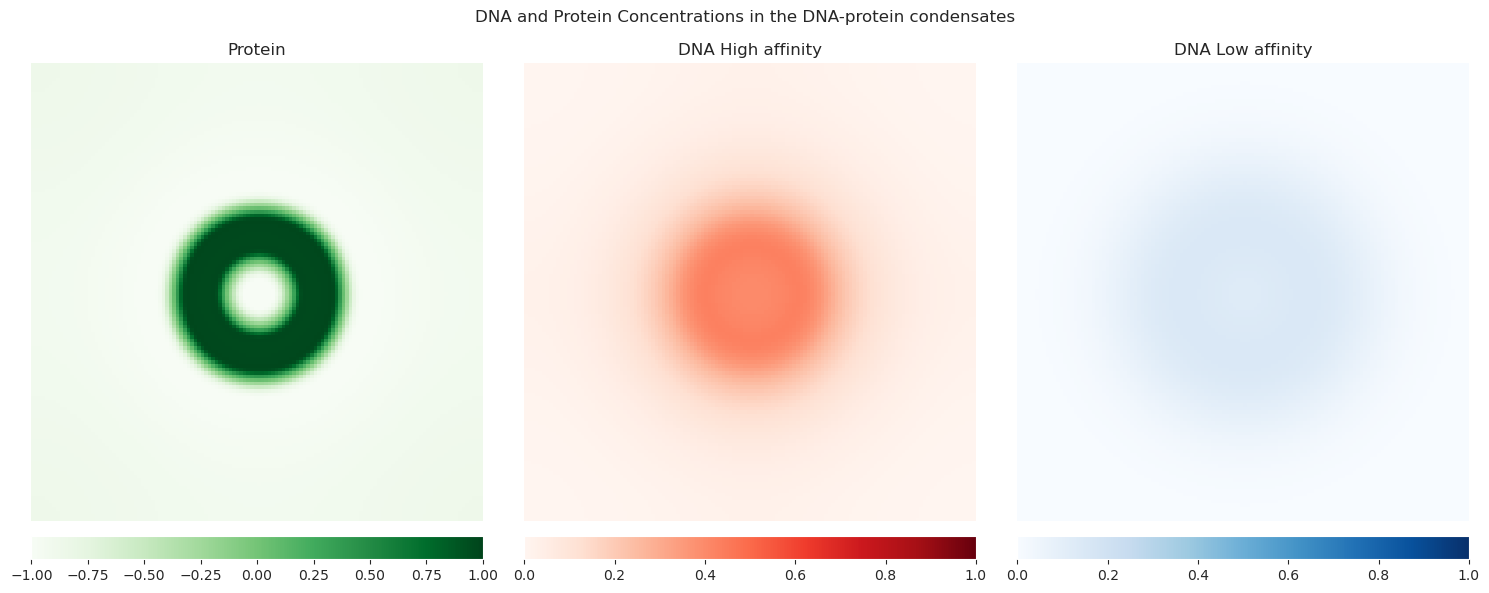

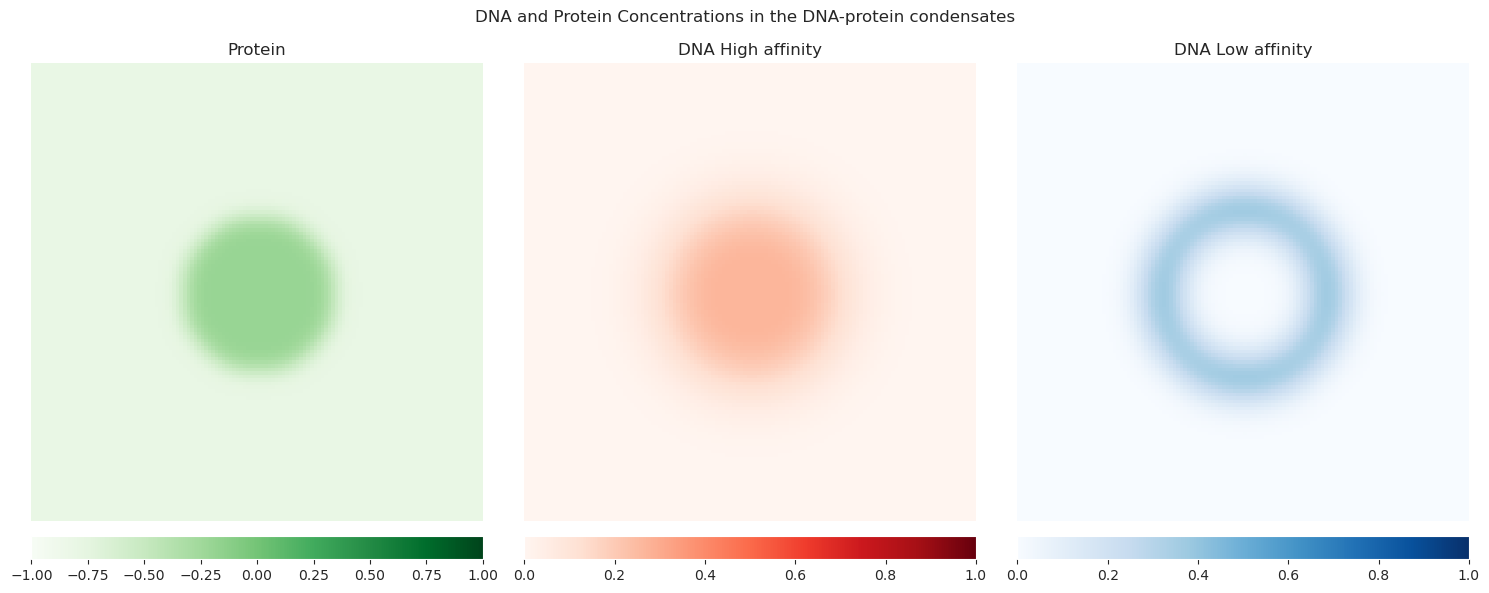

In [4]:
# Case 1: DNA_high enter the droplet for a shell
# While DNA_low cannot enter
para_high= {"m":128,"n":128,"dt":0.2,"max_iter":4000,
            "b1":0.14,"b2":0.4,"b3":-0.425,"b4":0.85,
            "Dd_0":3e-1,"dd_0":1e-4,"ad_0":1.5e-4,
            "Dd_1":1e-1,"dd_1":1e-4,"ad_1":0,
            "c1":0.6,"c2":0.6,"L1":1,"L2":1,"Critical":0.8,
            "alpha":0.008,"gamma":0,"beta":0,"base":0.3,"dna_level":0.5}
eta,phi,diffused_dna = init_dnadiff(para_high,dna_level_0=2,dna_level_1=2)
init_order = {"phi":torch.Tensor(phi),"eta":torch.Tensor(eta),"chi":{"0":torch.Tensor(diffused_dna["0"]),"1":torch.Tensor(diffused_dna["1"])}}
solver = Solver(para_high,init_order,logger=None,target_region="eta-phi",DNA=True,crit=0.15)
solver.initialize()
solver.solve(ifwrite=False,record_sequence=[0,4000])
result = solver.getResult()
start,final = map(result.get,[0,4000]) 
eta,phi,chi = final
fig_high_end = plotDP(chi,eta)
fig_high_end.suptitle("DNA and Protein Concentrations in the DNA-protein condensates")
fig_high_end.tight_layout()
fig_high_end.savefig("./ModifiedFigure/multi_highfirst_end.png",dpi=300)
eta,phi,chi = start
fig_high_start = plotDP(chi,eta)
fig_high_start.suptitle("DNA and Protein Concentrations in the DNA-protein condensates")
fig_high_start.tight_layout()
fig_high_start.savefig("./ModifiedFigure/multi_highfirst_start.png",dpi=300)

14.818675150051979


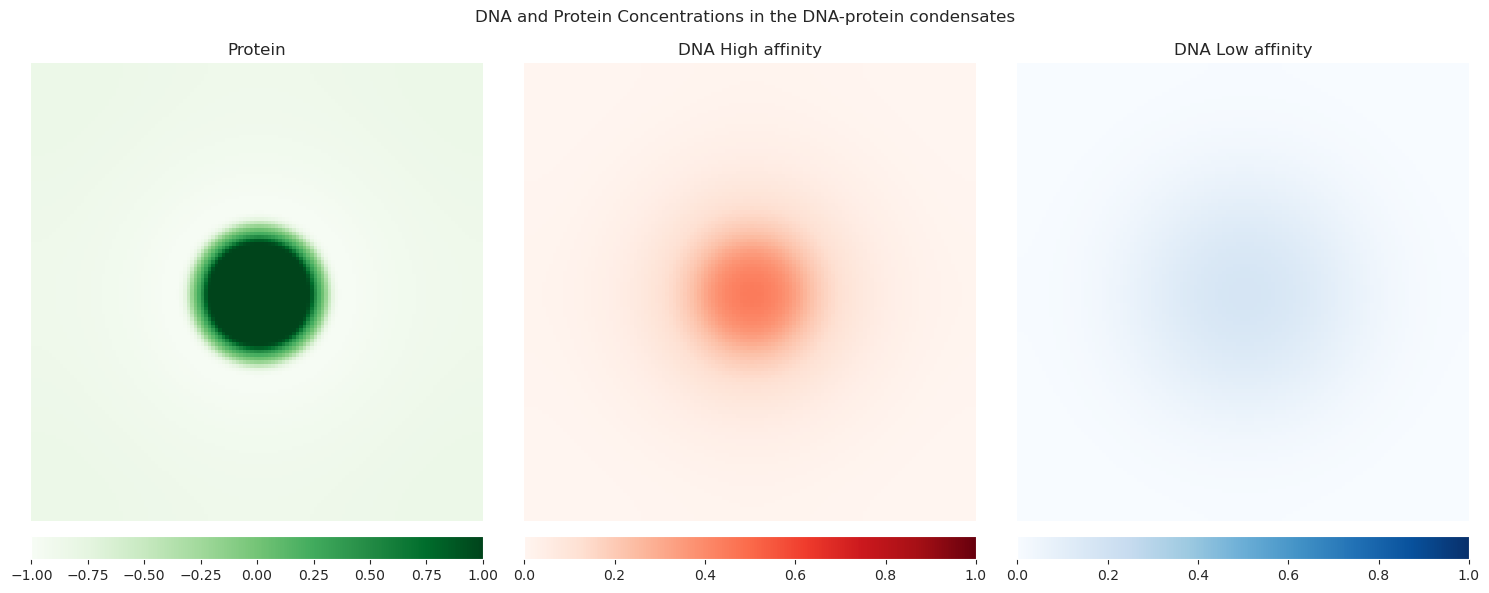

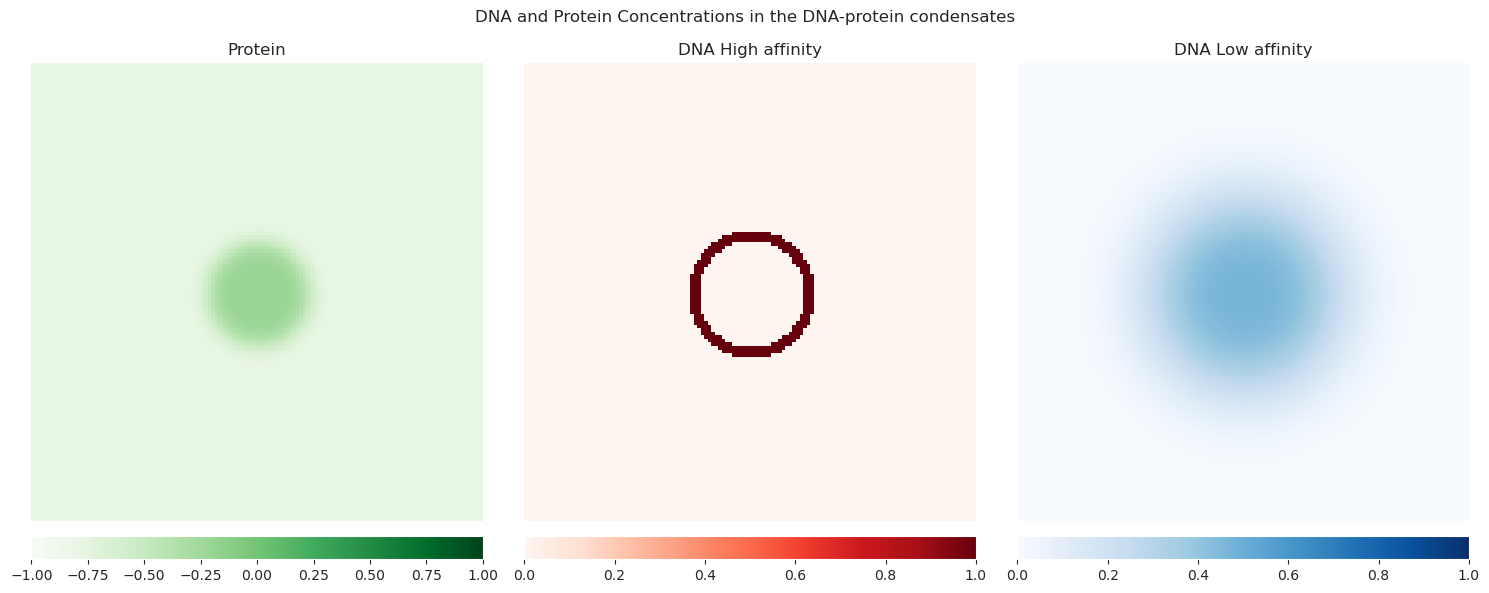

In [203]:
# Case 2 DNA_low first enter the droplet but got kicked out by DNA_high
# Yet cannot initialize a shell
total_step = 4000
para_low= {"m":128,"n":128,"dt":0.2,"max_iter":total_step,
            "b1":0.14,"b2":0.4,"b3":-0.425,"b4":0.85,
            "Dd_0":3e-1,"dd_0":5e-4,"ad_0":1.5e-4,
            "Dd_1":1e-1,"dd_1":1e-3,"ad_1":0,
            "c1":0.6,"c2":0.6,"L1":1,"L2":1,"Critical":0.8,
            "alpha":0.008,"gamma":0,"beta":0,"base":0.3,"dna_level":0.5}
eta,phi,diffused_dna = init_dnadiff(para_low,dna_level_0=2,dna_level_1=2,
                                    diffused_limit=['1'],dna_level_1_reset=2,diffused_time1=8000)
init_order = {"phi":torch.Tensor(phi),"eta":torch.Tensor(eta),"chi":{"0":torch.Tensor(diffused_dna["0"]),"1":torch.Tensor(diffused_dna["1"])}}
solver = Solver(para_low,init_order,logger=None,target_region="eta-phi",DNA=True,crit=0.15)
solver.initialize()
solver.solve(ifwrite=False,record_sequence=[0,total_step])
result = solver.getResult()
start,final = map(result.get,[0,total_step])
eta,phi,chi = final
fig_high_end = plotDP(chi,eta)
fig_high_end.suptitle("DNA and Protein Concentrations in the DNA-protein condensates")
fig_high_end.tight_layout()
fig_high_end.savefig("./ModifiedFigure/multi_lowfirst_end.png",dpi=300)
eta,phi,chi = start
fig_high_start = plotDP(chi,eta)
fig_high_start.suptitle("DNA and Protein Concentrations in the DNA-protein condensates")
fig_high_start.tight_layout()
fig_high_start.savefig("./ModifiedFigure/multi_lowfirst_start.png",dpi=300)